# Week 2 Assignment 1

**Name:** Meghana Balappa Uppar  
**USN:** [1GV22CS038]

# **1. Data Loading and Inspection**

In [ ]:
import pandas as pd

df = pd.read_csv("SuperMarket Analysis.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
# First 10 rows
df.head(10)

# Shape of dataset
df.shape

# Data types and missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


# **2. Data Cleaning and Preparation**

Handle Missing Values

In [ ]:
df = df.dropna()   # Since this dataset usually has minimal missing values

Convert Date Column

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

Create TotalSales Column

In [ ]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating', 'TotalSales'],
      dtype='object')

In [ ]:
# If not present:
df["TotalSales"] = df["Quantity"] * df["Unit price"]

# **3.Exploratory Data Analysis**



Top 3 Product Lines by Total Sales

In [ ]:
top_products = df.groupby("Product line")["TotalSales"].sum().sort_values(ascending=False).head(3)
print(top_products)

Product line
Food and beverages        53471.28
Sports and travel         52497.93
Electronic accessories    51750.03
Name: TotalSales, dtype: float64


Branch with Highest Average Sales

In [ ]:
branch_avg = df.groupby("Branch")["TotalSales"].mean().sort_values(ascending=False)
print(branch_avg)

Branch
Giza     321.047348
Cairo    304.640482
Alex     297.480029
Name: TotalSales, dtype: float64


Customer Type Distribution

In [ ]:
print(df["Customer type"].value_counts())

Customer type
Member    565
Normal    435
Name: count, dtype: int64


Average Spending by Customer Type

In [ ]:
customer_spending = df.groupby("Customer type")["TotalSales"].mean()
print(customer_spending)

Customer type
Member    319.755186
Normal    291.783218
Name: TotalSales, dtype: float64


# **4. Visualizations**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Bar Chart – Total Sales by Product Line

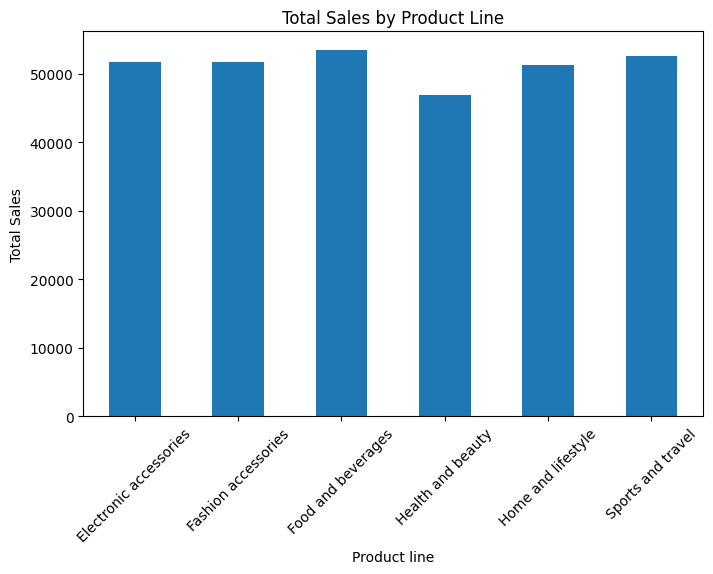

In [ ]:
plt.figure(figsize=(8,5))
df.groupby("Product line")["TotalSales"].sum().plot(kind="bar")
plt.title("Total Sales by Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

Box Plot – Sales Distribution Across Branches

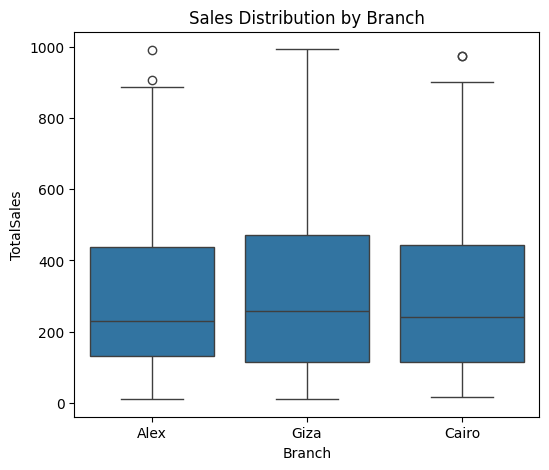

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Branch", y="TotalSales", data=df)
plt.title("Sales Distribution by Branch")
plt.show()

Histogram – TotalSales

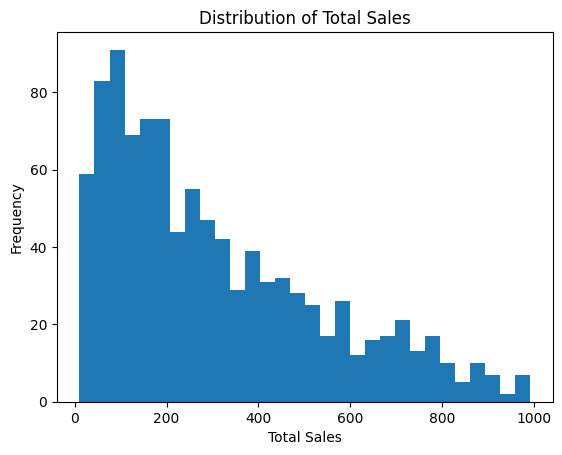

In [ ]:
plt.figure()
plt.hist(df["TotalSales"], bins=30)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

Pairplot (Numerical Features)

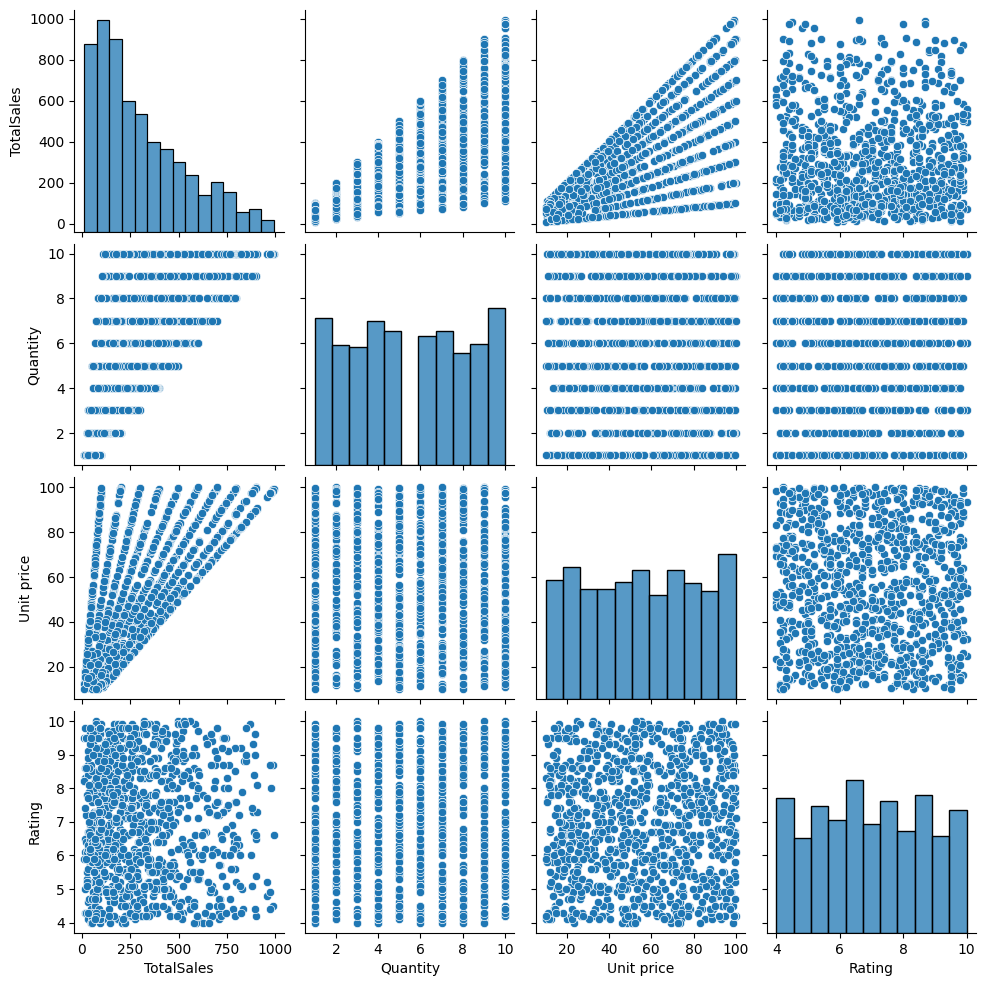

In [ ]:
sns.pairplot(df[["TotalSales", "Quantity", "Unit price", "Rating"]])
plt.show()

Correlation Heatmap

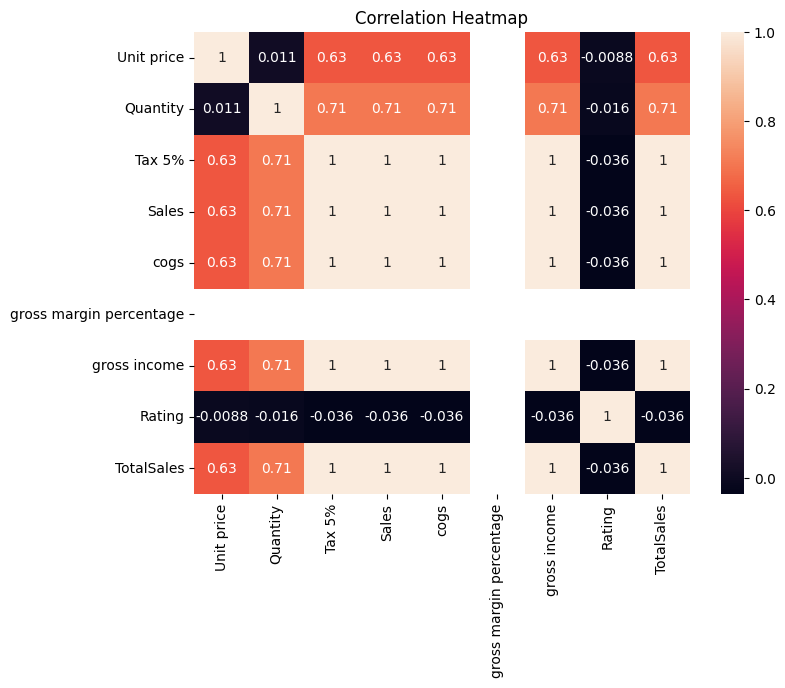

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# **5. Analytical Insight Answers**

1.Which product line generates consistent sales regardless of branch?

By analyzing the box plot and grouped sales data, the product line with smaller variation across branches indicates consistent performance. This suggests stable customer demand across locations.






2.Does gender have a significant influence on average sales value?

If the average sales value between males and females is similar, gender does not significantly influence sales. If there is a noticeable difference, marketing strategies can be adjusted accordingly.

In [ ]:
df.groupby("Gender")["TotalSales"].mean()

,TotalSales
Gender,
Female,324.696585
Male,284.814988


3.Suggest one insight that could support a business decision.

One key insight from the analysis is that certain product lines contribute significantly more to total revenue. The company can focus on promoting high-performing categories and improving inventory management for low-performing ones to increase profitability.